<div style="border-radius:10px;overflow:hidden;font-family:Aptos,Calibri,Segoe UI,sans-serif;border:1px solid #e6e9ee">
  <div style="background:#0A2540;padding:18px 22px;color:#fff">
    <div style="font-size:12px;letter-spacing:2px;color:#F4B942;font-weight:700">CARISURG · MEDTECH PATHWAYS · WEEK 5 · TUTORIAL 4</div>
    <div style="font-size:24px;font-weight:700;margin-top:4px">Exploratory Visualisation</div>
    <div style="font-size:14px;color:#cdd6df;margin-top:6px">A data-quality dashboard: missingness, acuity, demographics, complaints, vitals.</div></div>
  <div style="background:#F4B942;color:#0A2540;padding:6px 22px;font-size:12px;font-weight:700;letter-spacing:1px">STUDENT NOTEBOOK</div></div>

## Goal
Build the dashboard the memo needs (the brief asks for **4+ plots**, including **race/ethnicity** and **chief-complaint** views):
1. Missingness (structured, before cleaning) · 2. ESI class balance + age · 3. **Race/ethnicity distribution** ·
4. **Top chief complaints** · 5. Vitals by ESI · 6. Correlation (vitals + ESI) & complaint↔acuity.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Build the six-plot dashboard yourself. Each plot cell below is a TODO with the exact pandas/matplotlib calls named in its comments — fill them in and save each figure to <code>figs/</code>. By the end you have the 4+ committed figures (including race/ethnicity and chief complaints) the Tutorial 5 memo needs.</div>

## 1 · Setup & load cleaned (rebuilds from raw if needed)

In [113]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
# Run this cell first. These are the three libraries we use all week.
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [115]:
# ── Schema map ────────────────────────────────────────────────────────────────
# This dataset has ~225 columns, so we never list them by hand. We sort them into
# "families" once, then refer to the families by name for the rest of the week.

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [116]:
# Reference ranges for general adult triage. Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

In [117]:
import os
def clean_triage(raw):
    """Canonical Week-5 cleaning pipeline (the same steps you build in Tutorial 3).
    Takes the raw DataFrame and returns a cleaned copy."""
    d = raw.copy()
    fam = classify_columns(d)

    # 1. Drop rows with no triage label — we cannot learn a decision the data never recorded.
    d = d[d[TARGET].notna()].copy()

    # 2. Make the vital-sign columns (and age) numeric. Any stray text becomes NaN.
    numeric_cols = list(fam["vitals"])          # a copy of the vital-column list
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # 3. Flag physiologically impossible values as missing (NaN) — do not "cap" them.
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # 4. Fill the gaps. Vitals -> median (a robust middle value).
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    # A blank oxygen-device flag or chief-complaint flag means "not recorded" = 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 5. The target should be a whole number 1-5, not a decimal.
    d[TARGET] = d[TARGET].round().astype(int)
    return d

In [118]:
from pathlib import Path

CLEAN_PATH, RAW_PATH = Path("triage_cleaned_v1.csv.csv"), Path("/content/drive/MyDrive/Carisurg/yaleemmlc_admissionprediction_triage.csv")
if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH); print("Loaded cleaned data from Tutorial 3")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0)); print("Rebuilt from raw via clean_triage()")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or the raw CSV.")
raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True); print(df.shape)

Rebuilt from raw via clean_triage()
(55121, 225)


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>Path('triage_cleaned_v1.csv').exists()</code> just asks ‘is this file here?’. The cell loads the cleaned file if Tutorial 3 produced it, otherwise rebuilds it from the raw CSV with <code>clean_triage(...)</code> — so the notebook runs even on a fresh machine. <code>index_col=0</code> tells <code>read_csv</code> the first column is the row label, not data.</div>

## 2 · Plot 1 — Missingness before cleaning (structured)

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 1.</b> Show <i>where</i> data is missing before cleaning, as a heatmap of the missing-cell grid. Think: which matplotlib calls turn a True/False grid into a picture and label its columns?</div>

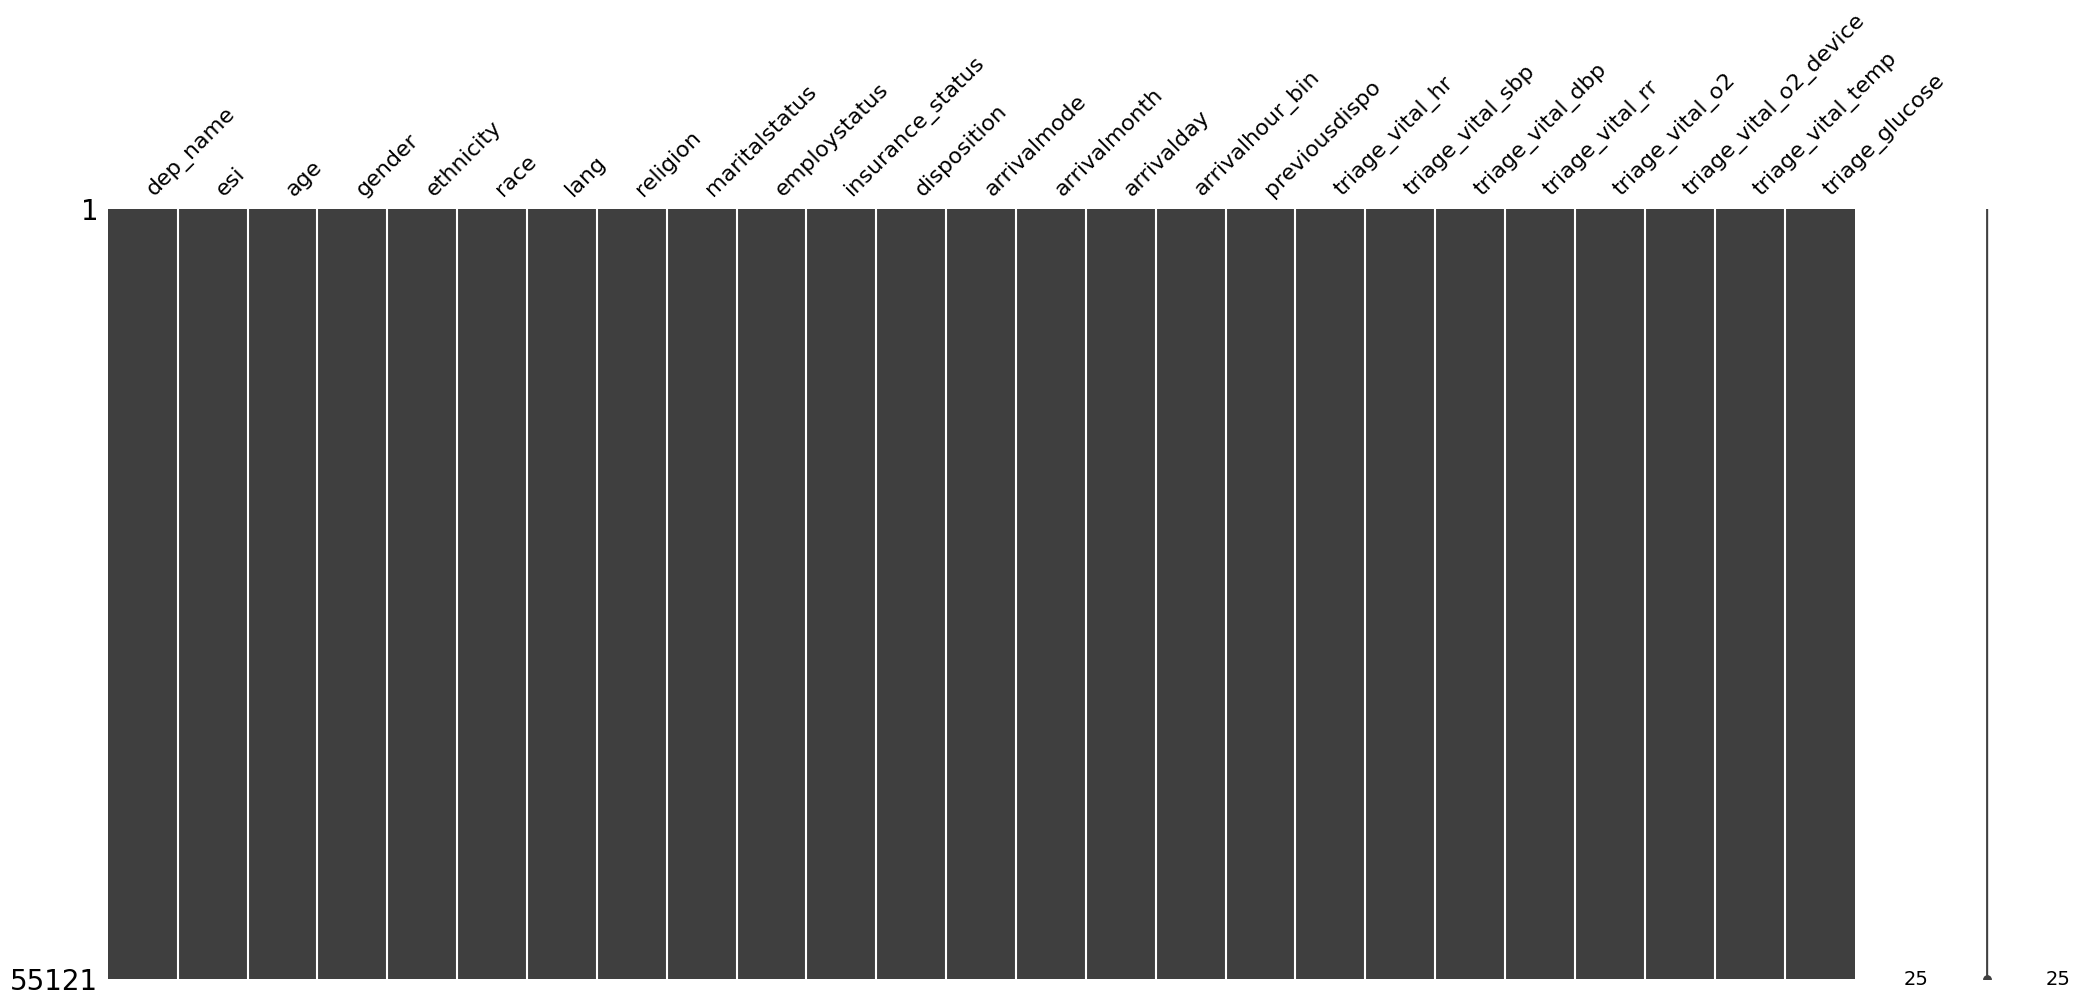

In [119]:
# TODO — draw a missingness map of src[structured] and save it.
#  - the missing-cell grid is src[structured].isna().values   (True where missing)
#  - make a figure + axes with plt.subplots(...)
#  - paint the grid with ax.imshow(...); look up the aspect= and cmap= args so missing reads as dark
#  - label the columns with ax.set_xticks(...) and ax.set_xticklabels(...) (rotate them so they fit)
#  - finish: plt.tight_layout(), then plt.savefig("figs/01_missingness.png", dpi=110), then plt.show()

src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]

missing_pct = src[structured].isna().mean().sort_values(ascending=True) * 100

src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]
try:
    import missingno as msno
    msno.matrix(src[structured]); plt.savefig("figs/01_missingness.png", dpi=110, bbox_inches="tight"); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4)); ax.imshow(src[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    plt.tight_layout(); plt.savefig("figs/01_missingness.png", dpi=110); plt.show()

In [120]:
print("\n% NaN per column (top 10):")
pct = (src[structured].isna().mean() * 100).sort_values(ascending=False)
print(pct.head(10).to_string(float_format=lambda x: f"{x:6.2f}%"))


% NaN per column (top 10):
dep_name          0.00%
esi               0.00%
age               0.00%
gender            0.00%
ethnicity         0.00%
race              0.00%
lang              0.00%
religion          0.00%
maritalstatus     0.00%
employstatus      0.00%


## 3 · Plot 2 — ESI class balance & age

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 2.</b> Two panels in one figure: a <b>bar chart</b> of how many patients sit at each ESI level, and a <b>histogram</b> of age. Decide which matplotlib call draws bars and which draws a histogram.</div>

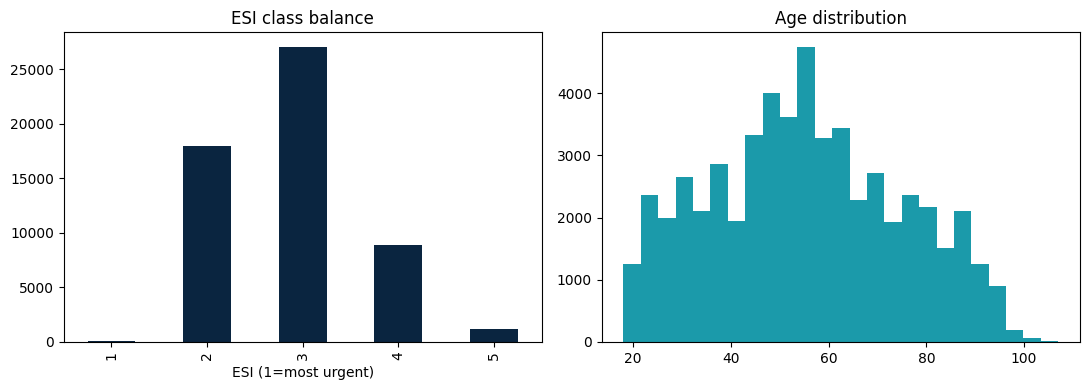

In [121]:
# TODO left panel (ax[0]) — ESI class balance as a BAR chart:
#   - count patients per ESI level with df[TARGET].value_counts(), then .sort_index()
#   - draw that Series with .plot.bar(ax=ax[0], ...)   (or use ax[0].bar(...))
#   - label it with ax[0].set_title(...) and ax[0].set_xlabel(...)
# TODO right panel (ax[1]) — age as a HISTOGRAM:
#   - use ax[1].hist(...) on df["age"] (choose a bins= value)
#   - give it a title with ax[1].set_title(...)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Left panel: how many patients fall into each ESI level.
esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0], color="#0A2540")
ax[0].set_title("ESI class balance")
ax[0].set_xlabel("ESI (1=most urgent)")

# Right panel: the spread of patient ages.
ax[1].hist(df["age"], bins=25, color="#1B9AAA")
ax[1].set_title("Age distribution")

plt.tight_layout()
plt.savefig("figs/02_esi_age.png", dpi=110)
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>plt.subplots(1, 2, ...)</code> makes a figure with a row of panels; <code>ax[0]</code> and <code>ax[1]</code> are the left and right panels you draw into. And you can plot straight from pandas: <code>some_series.plot.bar(ax=ax[0])</code> draws that Series as bars in a chosen panel — no need to hand matplotlib the x and y separately.</div>

## 4 · Plot 3 — Race & ethnicity (required, and a fairness lens)

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 3 (required).</b> Two horizontal bar charts — the race and ethnicity make-up of the sample. This is the equity view, so the categories must be readable; consider why horizontal bars help here.</div>

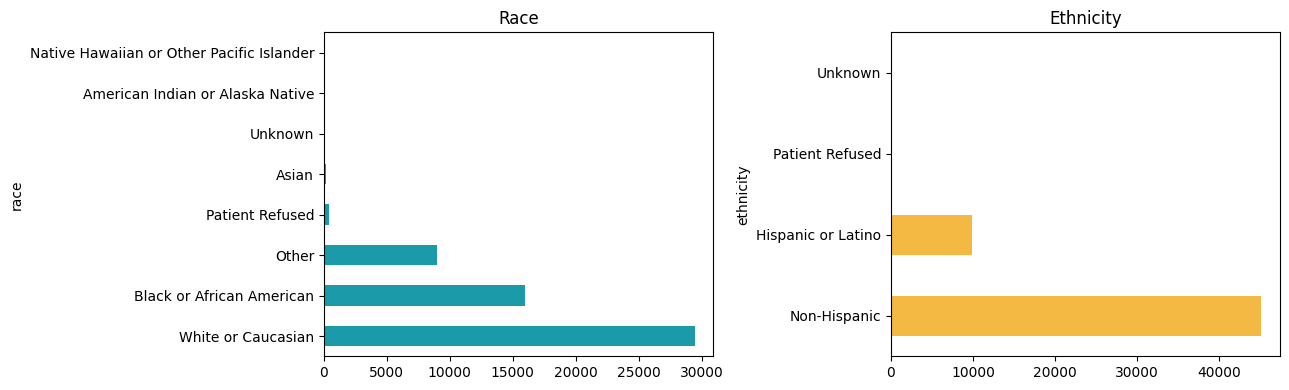

In [122]:
# TODO ax[0] — Race as a HORIZONTAL bar chart:
#   - tally the categories with df["race"].value_counts()
#   - draw it with .plot.barh(ax=ax[0], ...)   (barh = horizontal, good for long labels)
#   - title it with ax[0].set_title(...)
# TODO ax[1] — Ethnicity the same way, drawn into ax[1].

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# value_counts() tallies each category; .plot.barh() draws a horizontal bar chart.
df["race"].value_counts().plot.barh(ax=ax[0], color="#1B9AAA")
ax[0].set_title("Race")

df["ethnicity"].value_counts().plot.barh(ax=ax[1], color="#F4B942")
ax[1].set_title("Ethnicity")

plt.tight_layout()
plt.savefig("figs/03_demographics.png", dpi=110)
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df['race'].value_counts()</code> tallies how many patients fall in each category; chaining <code>.plot.barh()</code> draws those tallies as a horizontal bar chart in one line. <code>barh</code> (horizontal) is the friendly choice when category names are long — they read left-to-right instead of overlapping under a vertical axis.</div>

<div style="border-left:4px solid #1B9AAA;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>Read this plot as an equity check: if one group dominates the sample, a model may underperform for everyone else — and this US sample may look nothing like a Caribbean ED. That sentence belongs in the memo's caveats.</div>

## 5 · Plot 4 — Top chief complaints (required)

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 4 (required).</b> Rank the chief-complaint flags and show the top 15 as a horizontal bar chart, biggest bar on top. Think about how to turn 200 0/1 columns into one count per complaint.</div>

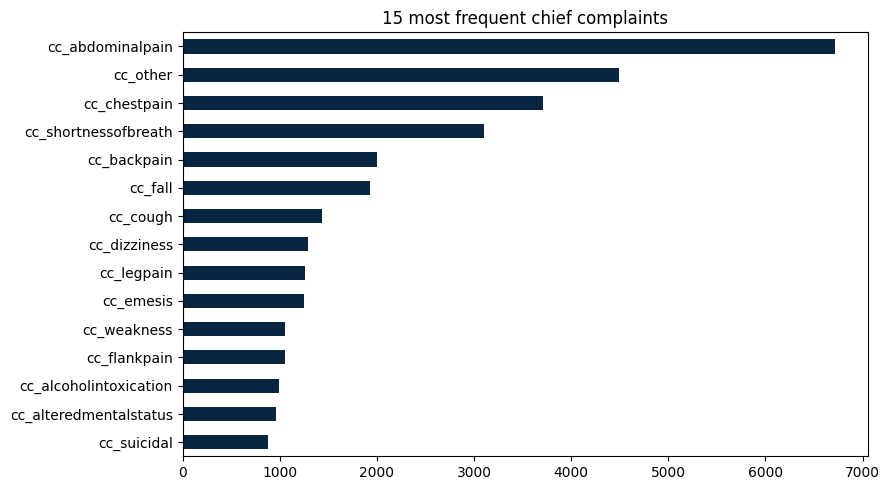

In [123]:
# TODO — top 15 chief complaints as a horizontal bar chart, biggest bar on top.
#  - count each complaint by summing the 0/1 flags: df[fam["chief_complaints"]].sum()
#  - sort it descending (.sort_values(...)) and keep the top 15 (.head(...))
#  - make the axes with plt.subplots(...)
#  - draw with .plot.barh(...); reverse the order with [::-1] so the biggest bar is on top
#  - title it, then plt.tight_layout() / plt.savefig("figs/04_chief_complaints.png", dpi=110) / plt.show()

# Sum each cc_ column to count how often each complaint occurs, then take the top 15.
complaint_counts = df[fam["chief_complaints"]].sum().sort_values(ascending=False)
top15 = complaint_counts.head(15)

fig, ax = plt.subplots(figsize=(9, 5))
# top15[::-1] reverses the order so the biggest bar ends up at the TOP of a horizontal chart.
top15[::-1].plot.barh(ax=ax, color="#0A2540")
ax.set_title("15 most frequent chief complaints")

plt.tight_layout()
plt.savefig("figs/04_chief_complaints.png", dpi=110)
plt.show()


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[fam['chief_complaints']].sum()</code> counts each complaint (summing 0/1 flags), and <code>.head(15)</code> keeps the 15 biggest after sorting. <code>top15[::-1]</code> is a <b>reverse slice</b> — ‘same items, back to front’ — used so the largest bar lands at the <i>top</i> of a horizontal chart instead of the bottom.</div>

In [124]:
print("-" * 70); print("PLOT 4 DIAGNOSTIC — chief complaints"); print("-" * 70)
cc_cols = fam["chief_complaints"]
print(f"# cc_ columns: {len(cc_cols)}")

----------------------------------------------------------------------
PLOT 4 DIAGNOSTIC — chief complaints
----------------------------------------------------------------------
# cc_ columns: 200


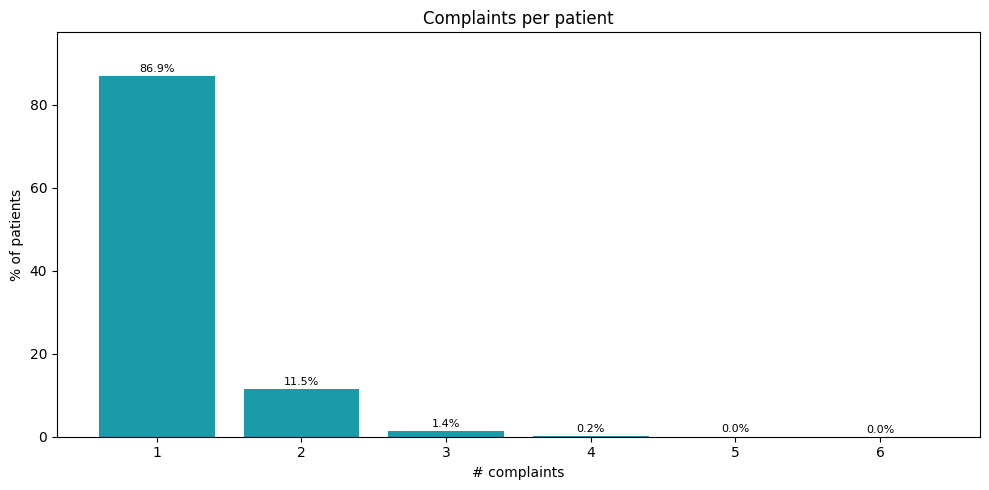

In [125]:
# --- Complaints-per-patient distribution ---
cc_cols = fam["chief_complaints"]

per_row = df[cc_cols].sum(axis=1).astype(int)
dist = per_row.value_counts().sort_index()
dist_pct = dist / dist.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(dist_pct.index.astype(str), dist_pct.values, color="#1B9AAA")
ax.set_title("Complaints per patient")
ax.set_xlabel("# complaints")
ax.set_ylabel("% of patients")

for i, v in enumerate(dist_pct.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=8)

ax.set_ylim(0, dist_pct.max() * 1.12)

plt.tight_layout()
plt.savefig("figs/04b_complaints_per_patient.png", dpi=110)
plt.show()

## 6 · Plot 5 — Do vitals separate the ESI classes?

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 5.</b> A 2×3 grid of box-plots — one panel per vital, one box per ESI level — so you can see which vitals separate the acuity classes. Which matplotlib call draws a box-plot from a list of value groups?</div>

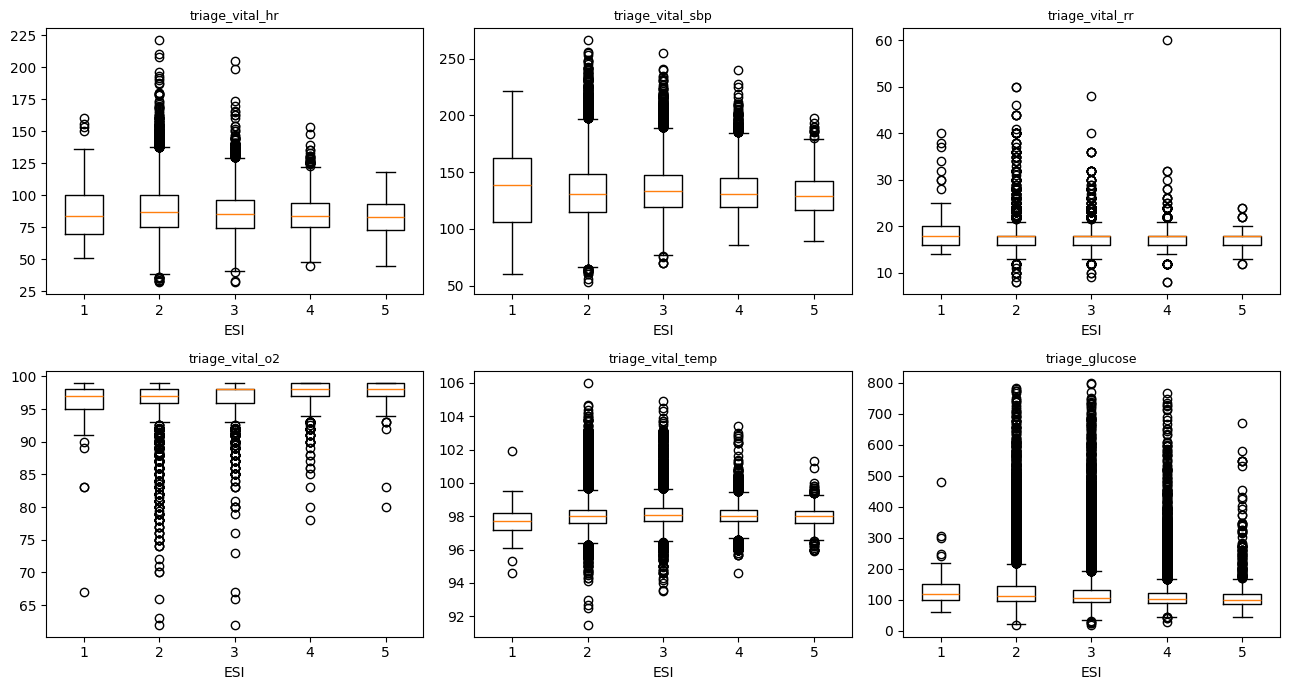

In [126]:
    # TODO — one box per ESI level for this vital:
    #   - build a list "groups": for each level in esi_levels, take df.loc[df[TARGET] == level, col]
    #   - draw them with panel.boxplot(...) (pass tick_labels= so each box is labelled by ESI level)
    #   - title the panel with panel.set_title(col, ...) and label the x-axis "ESI"

    # One box-plot per vital, with a separate box for each ESI level, so we can SEE whether
# the vital differs across acuity levels.
vitals_to_plot = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_rr",
                  "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

esi_levels = sorted(df[TARGET].unique())                 # e.g. [1, 2, 3, 4, 5]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for panel, col in zip(axes.ravel(), vitals_to_plot):
    # Collect this vital's values for each ESI level into a list of groups.
  groups = []
  for level in esi_levels:
        values_at_level = df.loc[df[TARGET] == level, col]
        groups.append(values_at_level)

  panel.boxplot(groups, tick_labels=esi_levels)
  panel.set_title(col, fontsize=9)
  panel.set_xlabel("ESI")

plt.tight_layout()
plt.savefig("figs/05_vitals_by_esi.png", dpi=110)
plt.show()



<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[TARGET] == level</code> is a True/False mask over the rows. <code>df.loc[mask, col]</code> then reads just one column for just the rows where the mask is True — here, that vital’s values for one ESI level. Building one group per level gives the box-plot a separate box per acuity class, so you can <i>see</i> whether the vital separates them.</div>

## 7 · Plot 6 — Correlation (vitals + ESI) and complaint↔acuity

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 6.</b> Draw the vitals+ESI correlation matrix as a colour-coded heatmap with the number written in each cell. Think about the matplotlib calls that paint a grid, write text in a cell, and add a colour scale.</div>

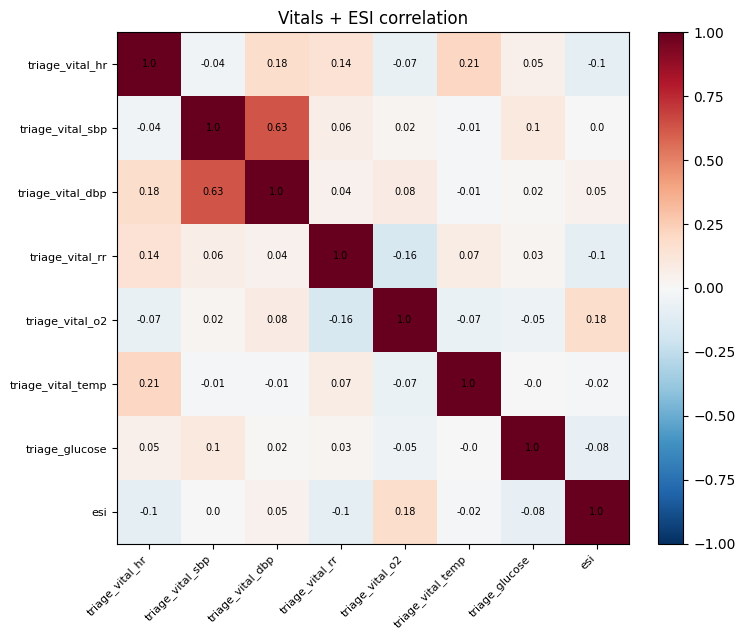

In [127]:
# TODO — draw the correlation matrix as a labelled heatmap.
#  - make a figure + axes with plt.subplots(...)
#  - paint the matrix with ax.imshow(corr, ...); a diverging cmap with vmin=-1, vmax=1 reads well
#  - label both axes from cols using ax.set_xticks/ax.set_xticklabels and ax.set_yticks/ax.set_yticklabels
#  - write each number: loop i over rows and j over cols, and ax.text(j, i, <the value at corr.iloc[i, j]>)
#  - add a scale with fig.colorbar(...), give it a title
#  - plt.tight_layout(), plt.savefig("figs/06_correlation.png", dpi=110), plt.show()

# Correlation heatmap of the vitals plus the ESI target.
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()                         # a square table of correlations (-1..1)

fig, ax = plt.subplots(figsize=(7.5, 6.5))

heat = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)   # colour each cell by its value

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=8)

ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=8)

# Write the numbers inside each cell (row i, column j) so the heatmap is readable.
for i in range(len(cols)):
    for j in range(len(cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, round(value, 2), ha="center", va="center", fontsize=7)

fig.colorbar(heat, fraction=0.046)
ax.set_title("Vitals + ESI correlation")

plt.tight_layout()
plt.savefig("figs/06_correlation.png", dpi=110)
plt.show()


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[cols].corr()</code> returns a square table — every column correlated with every other (the diagonal is always 1). <code>corr.iloc[i, j]</code> reads a cell by <b>position</b> (row number i, column number j), which is why the double loop can write each number onto the heatmap. <code>imshow</code> just paints that table as coloured squares.</div>

## 8 · Exercises
1. Complete all six plots and save them to `figs/`.
2. Which vital separates the ESI classes best? Worst? One sentence each.
3. Cross-tabulate `cc_chestpain` against ESI — does it skew urgent as expected?
4. Add one equity plot: ESI distribution *within* each race category. What would worry a clinician?

**Which vital separates the ESI classes best? Worst?**
The vital that separates ESI classes best is oxygen (triage_vital_o2) because it has the strongest correlation with ESI and shows the clearest difference between acuity groups,  although the relationship is still weak overall.

The vital that separates ESI classes worst is systolic blood pressure (triage_vital_sbp) because its correlation is essentially zero, meaning it does not clearly distinguish between acuity groups.


In [128]:
# Cross-tabulate chest pain against ESI

chestpain_counts = pd.crosstab(df["cc_chestpain"], df[TARGET])
print("Counts:")
print(chestpain_counts)

chestpain_pct = pd.crosstab(df["cc_chestpain"], df[TARGET], normalize="index") * 100
print("\nRow percentages:")
print(chestpain_pct.round(1))

Counts:
esi            1      2      3     4     5
cc_chestpain                              
0.0           73  15730  25536  8858  1213
1.0            4   2194   1473    38     1
2.0            0      0      1     0     0

Row percentages:
esi             1     2      3     4    5
cc_chestpain                             
0.0           0.1  30.6   49.7  17.2  2.4
1.0           0.1  59.1   39.7   1.0  0.0
2.0           0.0   0.0  100.0   0.0  0.0


cc_chestpain = 0 means no chest pain complaint.
cc_chestpain = 1 means chest pain complaint.

This code compares the presence of chest pain with ESI triage level. The first crosstab shows the raw number of patients in each ESI category for each value of cc_chestpain. The second crosstab normalizes by row, so each chest pain group adds up to 100%, making it easier to compare the ESI distribution between patients with and without chest pain. This helps show whether chest pain patients are more concentrated in urgent ESI categories.

Chest pain skews urgent as expected because patients with cc_chestpain = 1 are much more concentrated in ESI 2 (59.1%) and much less likely to be ESI 4–5 compared with patients without chest pain.

esi                                          1     2     3     4     5
race                                                                  
American Indian or Alaska Native           0.0  33.3  53.0  10.6   3.0
Asian                                      0.0  42.9  44.6   9.7   2.9
Black or African American                  0.1  29.3  47.2  20.5   2.9
Native Hawaiian or Other Pacific Islander  5.0  50.0  10.0  20.0  15.0
Other                                      0.1  24.2  53.8  19.5   2.4
Patient Refused                            0.0  22.7  53.8  19.5   4.1
Unknown                                    0.0  25.0  50.0  19.7   5.3
White or Caucasian                         0.2  36.9  48.4  12.8   1.7


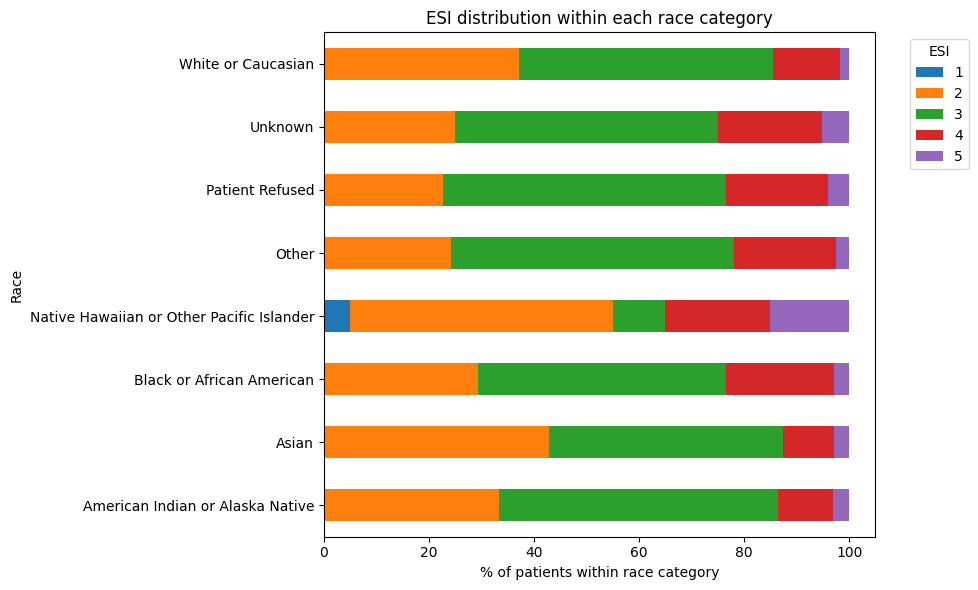

In [129]:
# Equity plot: ESI distribution within each race category

race_esi_pct = pd.crosstab(df["race"], df[TARGET], normalize="index") * 100
print(race_esi_pct.round(1))

fig, ax = plt.subplots(figsize=(10, 6))
race_esi_pct.plot(kind="barh", stacked=True, ax=ax)

ax.set_title("ESI distribution within each race category")
ax.set_xlabel("% of patients within race category")
ax.set_ylabel("Race")
ax.legend(title="ESI", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("figs/07_equity_race_esi.png", dpi=110)
plt.show()

The equity plot shows the percentage of patients in each ESI level within each race category.


A clinician would worry if one race category had a noticeably different ESI distribution from the others, especially if patients in that group appeared less likely to receive urgent ESI scores despite similar needs, since that could suggest possible under-triage or inequity in assessment.

## 9 · Wrap-up
Six committed figures. **Next — Tutorial 5: the Feasibility Memo.**